In [1]:
import os
import sys

from IPython.display import display, update_display, Image
import matplotlib.pyplot as plt

/home/local/KHQ/ayman.yousef/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:


# 1. Provide your EXACT absolute path to the ParaView directory
# (Change this path string to point to where your Linux directory is extracted)
paraview_base_path = "/home/local/KHQ/ayman.yousef/Downloads/paraview_with_qt/paraview_build/"
os.environ["PV_ALLOW_OFFSCREEN_RENDERING"] = "1"
# 2. Extract specific directory paths
pv_lib_dir = os.path.join(paraview_base_path, "lib")
pv_site_packages = os.path.join(pv_lib_dir, "python3.10", "site-packages")

# 3. Simulate terminal 'export LD_LIBRARY_PATH' using Python's env dictionary
existing_ld_path = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{pv_lib_dir}:{existing_ld_path}"

catalyst_ml_path = "~/Downloads/catalyst-ml/catalyst-ml/"
existing_pv_path = os.environ.get("PYTHONPATH", "")
os.environ["PYTHONPATH"]= f"{catalyst_ml_path}:{existing_pv_path}"

# 4. Inject the python module pathways at the absolute front of Python's lookup index
if pv_site_packages not in sys.path:
    sys.path.insert(0, pv_site_packages)

# 5. Attempt the initialization imports
try:
    from paraview.simple import *
    print("🚀 Success! ParaView loaded perfectly within VS Code.")
except ImportError as error:
    print(f"❌ Initialization failed. Technical error breakdown:\n{error}")


🚀 Success! ParaView loaded perfectly within VS Code.


In [3]:
import sys

import numpy as np
import torch
import time
import logging
import os
from fno2d_cylinder import CylinderFNO
sys.path.append("~/Downloads/catalyst-ml/catalyst-ml/")

from paraview.simple import *

from paraview.vtk.numpy_interface import dataset_adapter as dsa

from vtk.util import numpy_support
from vtkmodules.vtkCommonCore import vtkPoints
from vtkmodules.vtkCommonDataModel import vtkCellArray, vtkUnstructuredGrid
import vtkmodules.vtkCommonDataModel as vtk
import math
sys.path.append("/home/local/KHQ/ayman.yousef/Downloads/catalyst-ml/catalyst-ml/examples/cylinder_2d_fides")
from pn_autoencoder import PointCloudAE
import torch.nn as nn
logging.basicConfig(level=logging.INFO, format='[INFER] %(message)s')
logger = logging.getLogger(__name__)
from paraview import catalyst
from vtkmodules.vtkIOXML import vtkXMLUnstructuredGridWriter
xml_plugin_path = os.path.abspath("/home/local/KHQ/ayman.yousef/Downloads/paraview_with_qt/paraview/Remoting/Application/Resources/proxies_fides.xml")
LoadPlugin(xml_plugin_path, ns=globals())


In [4]:

def make_view():
    rv = CreateView('RenderView')
    rv.ViewSize = [1200, 400]
    rv.UseColorPaletteForBackground = 0
    rv.Background = [1.0, 1.0, 1.0]
    rv.OrientationAxesVisibility = 0
    rv.InteractionMode = '2D'
    rv.CameraPosition = [75, 25, 100]
    rv.CameraFocalPoint = [75, 25, 0]
    rv.CameraViewUp = [0, 1, 0]
    rv.CameraParallelProjection = 1
    rv.CameraParallelScale = 30

    return rv

def visualize(model_pred, step):

    global fides

    # Omega coarse
    #rv1 = make_view()
    #d1 = Show(fides, rv1)
    #d1.Representation = 'Surface'
    #ColorBy(d1, ('POINTS', 'omega_coarse'))
    #lut1 = GetColorTransferFunction('omega_coarse')
    #lut1.ApplyPreset('Cool to Warm', True)
    #lut1.RescaleTransferFunction(-0.03, 0.03)
    #d1.SetScalarBarVisibility(rv1, True)
    #GetScalarBar(lut1, rv1).Title = 'omega (coarse)'

    #output_gt_png = f"./catalyst_output/gt_output-{step:05d}.png"
    #SaveScreenshot(output_gt_png, rv1, ImageResolution=[1200,400])

    # Predicted Omega + Coords

    ### * Generate grid from prediction

    sys.argv.append("--force-offscreen-rendering")

    pred_tp = gen_tp_from_model(model_pred)

    rv2 = make_view()
    cell_to_point = CellDatatoPointData(registrationName='CellToPoint', Input=pred_tp)

    d2 = Show(cell_to_point, rv2)
    d2.Representation = 'Surface'
    ColorBy(d2, ('POINTS', 'omega_coarse'))
    lut2 = GetColorTransferFunction('omega_coarse')
    lut2.ApplyPreset('Cool to Warm', True)
    lut2.RescaleTransferFunction(-0.03, 0.03)
    d2.SetScalarBarVisibility(rv2, True)
    sb2 = GetScalarBar(lut2, rv2)
    
    # 2. Change the Title properties using the variable
    sb2.Title = 'omega (coarse)'
    sb2.TitleColor = [0.0, 0.0, 0.0]      # Black
    sb2.TitleFontSize = 12
    sb2.TitleBold = 1                     # True
    
    # 3. Change the Label text properties using the variable
    sb2.LabelColor = [0.0, 0.0, 0.0]      # Black
    sb2.LabelFontSize = 10
    sb2.LabelBold = 0             # 1 for True, 0 for False

    SetActiveView(rv2)

    output_pred_png = f"./catalyst_output/pred_output-{step:05d}.png"
    SaveScreenshot(output_pred_png, rv2, ImageResolution=[1200,400])
    update_display(Image(output_pred_png), display_id="my_image_stream")

def visualize_alt(pred_tp, color_map_string):

    step = 100

    rv2 = make_view()
    cell_to_point = CellDatatoPointData(registrationName='CellToPoint', Input=pred_tp)

    d2 = Show(cell_to_point, rv2)
    d2.Representation = 'Surface'
    ColorBy(d2, ('POINTS', 'omega_coarse'))
    lut2 = GetColorTransferFunction('omega_coarse')
    lut2.ApplyPreset(color_map_string, True)
    lut2.RescaleTransferFunction(-0.03, 0.03)
    d2.SetScalarBarVisibility(rv2, True)
    GetScalarBar(lut2, rv2).Title = 'omega (coarse)'
    SetActiveView(rv2)

    output_pred_png = f"./catalyst_output/pred_output-{step:05d}.png"
    SaveScreenshot(output_pred_png, rv2, ImageResolution=[1200,400])
    update_display(Image(output_pred_png), display_id="my_image_stream")

    return pred_tp 

def gen_tp_from_model(prediction):

    output_grid = vtk.vtkUnstructuredGrid()

    coords_x = prediction[:, 0]
    coords_y = prediction[:, 1]
    coords_z = prediction[:, 2]

    omega_pred = prediction[:, 3] 
    vel_mag_pred = prediction[:, 4] 

    nx = 150
    ny = 50

    i_idx, j_idx = np.meshgrid(np.arange(nx - 1), np.arange(ny - 1), indexing='ij')
    p0 = i_idx * ny + j_idx
    p1 = (i_idx + 1) * ny + j_idx
    p2 = (i_idx + 1) * ny + (j_idx + 1)
    p3 = i_idx * ny + (j_idx + 1)

    conn = np.stack([p0, p1, p2, p3], axis=-1).flatten()
    num_cells = (nx - 1) * (ny - 1)

    coords = np.concatenate((np.expand_dims(coords_x, axis=-1), np.expand_dims(coords_y, axis=-1), np.expand_dims(coords_z, axis=-1)), axis=-1)
    offsets = np.arange(0, (num_cells + 1) * 4, 4, dtype=np.int64)
    connectivity = conn.flatten().astype(np.int64)

    vtk_offsets = numpy_support.numpy_to_vtkIdTypeArray(offsets, deep=True)
    vtk_connectivity = numpy_support.numpy_to_vtkIdTypeArray(connectivity, deep=True)

    pts = vtkPoints()
    pts.SetData(numpy_support.numpy_to_vtk(coords, deep=True))
    output_grid.SetPoints(pts)

    cells = vtkCellArray()
    cells.SetData(vtk_offsets, vtk_connectivity)

    cell_types = np.full(num_cells, vtk.VTK_QUAD, dtype=np.uint8)
    vtk_cell_types = numpy_support.numpy_to_vtk(cell_types, deep=True)
    output_grid.SetCells(vtk_cell_types, cells)


    vtk_field_omega = numpy_support.numpy_to_vtk(omega_pred.flatten(), deep=True)
    vtk_field_omega.SetName("omega_coarse")

    vtk_field_vel = numpy_support.numpy_to_vtk(vel_mag_pred.flatten(), deep=True)
    vtk_field_vel.SetName("vel_mag")

    output_grid.GetPointData().AddArray(vtk_field_omega)
    output_grid.GetPointData().SetActiveScalars("omega_coarse")

    output_grid.GetPointData().AddArray(vtk_field_vel)
    output_grid.GetPointData().SetActiveScalars("vel_mag")

    tp = TrivialProducer()
    tp.GetClientSideObject().SetOutput(output_grid)


    writer = vtkXMLUnstructuredGridWriter()
    writer.SetFileName("output_mesh.vtu")
    writer.SetInputData(output_grid)

    # Optional: set compression options
    writer.SetDataModeToBinary() # or SetDataModeToAscii()

    writer.Write()
    return tp

def read_from_fides():
    global fides

    status = NotReady
    while status == NotReady:
        # must call PrepareNextStep to get Fides ready to read the
        # next step
        fides.PrepareNextStep()
        fides.UpdatePipelineInformation()
        status = fides.NextStepStatus
    fides.UpdatePipeline()

    # fides object treated as PartitionedDataSetCollection 

    # surf_data = surface_producer.GetClientSideObject().GetOutputDataObject(0)

    merged_source = MergeBlocks(fides)

    data = paraview.servermanager.Fetch(merged_source)
    point_data = data.GetPointData()

    omega = numpy_support.vtk_to_numpy(point_data.GetArray("omega_coarse"))
    ux =  numpy_support.vtk_to_numpy(point_data.GetArray("ux"))
    uy =  numpy_support.vtk_to_numpy(point_data.GetArray("uy"))

    coords = data.GetPoints().GetData()

    return omega, ux, uy, coords
    # Gather the actual arrays from here 


def normalize_robust(x, lo_pct=1, hi_pct=99, eps=1e-8):
    lo = np.percentile(x, lo_pct)
    hi = np.percentile(x, hi_pct)
    if hi - lo < eps:
        lo, hi = x.min() - eps, x.max() + eps
    return 2.0 * (np.clip(x, lo, hi) - lo) / (hi - lo) - 1.0, lo, hi


def denormalize(y, lo, hi):
    return (y + 1.0) / 2.0 * (hi - lo) + lo


def preprocess(features):
    """Normalize coarse state using its own per-channel percentiles."""
    channels = []
    ranges = []
    for name in ['omega', 'ux', 'uy']:
        normed, lo, hi = normalize_robust(features[name])
        channels.append(normed)
        ranges.append((lo, hi))
    st = np.stack(channels, axis=0)
    return st[np.newaxis, ...], ranges  # (1, 3, 150, 50), [(lo,hi)*3]


def postprocess(output, ranges):
    """Denormalize FNO output using the same ranges as input."""
    return {
        'omega_rom': denormalize(output[0], *ranges[0]).astype(np.float32),
        'ux_rom': denormalize(output[1], *ranges[1]).astype(np.float32),
        'uy_rom': denormalize(output[2], *ranges[2]).astype(np.float32),
    }


def train_loop(features, step):
    num_epochs = 5
    step_avg_loss = 0
    global global_epoch, training_losses, model, optimizer, criterion
    for epoch in range(num_epochs):
        batch_temp = 0
        running_loss = 0.0
        optimizer.zero_grad()  
        outputs = model(features)
        loss = criterion(outputs, features)
        running_loss += loss.item()
        loss.backward()        
        optimizer.step() 
        batch_temp+=1
        epoch_loss = running_loss / len(features)
        training_losses.append(epoch_loss)
        step_avg_loss +=epoch_loss
    step_avg_loss = step_avg_loss/num_epochs
    global_epoch+=num_epochs

    #print("STEP {} AVG. LOSS: {}".format(step, step_avg_loss))

    # visualize the last prediction from the model
    visualize(np.squeeze(outputs.detach().numpy(), axis=0), step)
    return step_avg_loss



In [5]:
NotReady = 1
EndOfStream = 2

NUMPOINTS=7500
LATENTSIZE=128

fides=FidesJSONReader()
fides.DataSourceEngines = ["source", "SST"]


model = PointCloudAE(NUMPOINTS, LATENTSIZE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
global_epoch = 0
training_losses = []

(   2.251s) [paraview        ]     vtkFidesReader.cxx:533   WARN| vtkFidesReader (0x5b23b2a87ce0): Exception encountered when trying to set up Fides DataSetReader: Unable to open metadata file; does '' exist?: iostream error


In [6]:
fides.DataSourcePath = ["source", "/home/local/KHQ/ayman.yousef/Downloads/catalyst-ml/catalyst-ml/examples/2d_cyl.gp"]
fides.StreamSteps = 1
fides.FileName = "./flow.json"
fides.PrepareNextStep()
fides.UpdatePipelineInformation()

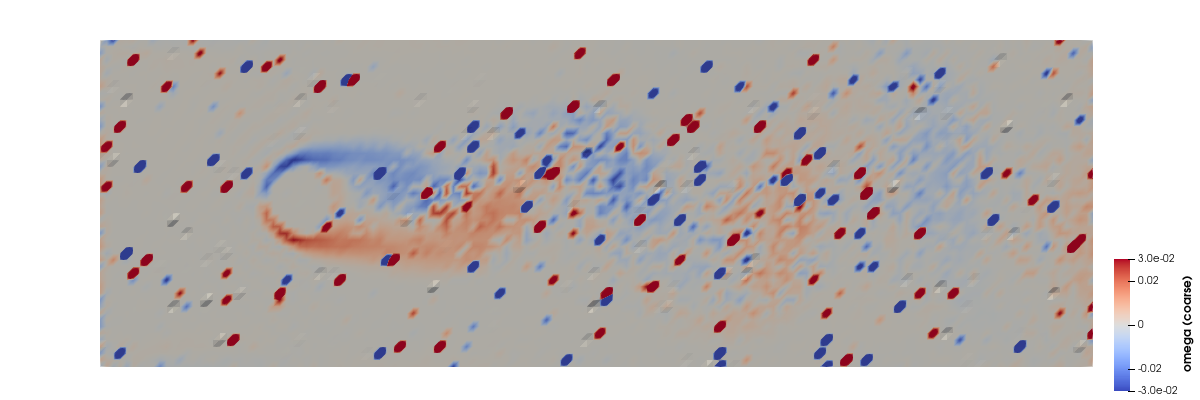

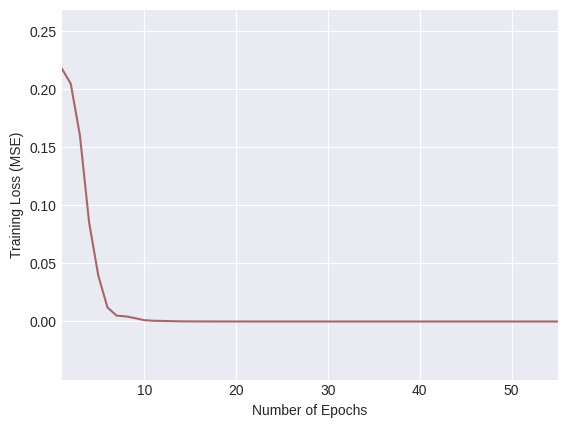

/home/local/KHQ/ayman.yousef/.local/lib/python3.10/site-packages/torch/nn/modules/loss.py:630: UserWarning: Using a target size (torch.Size([7500, 5])) that is different to the input size (torch.Size([1, 7500, 5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/tmp/ipykernel_1205150/548876810.py:50: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(epochs[0], epochs[-1])
[INFER] Done.


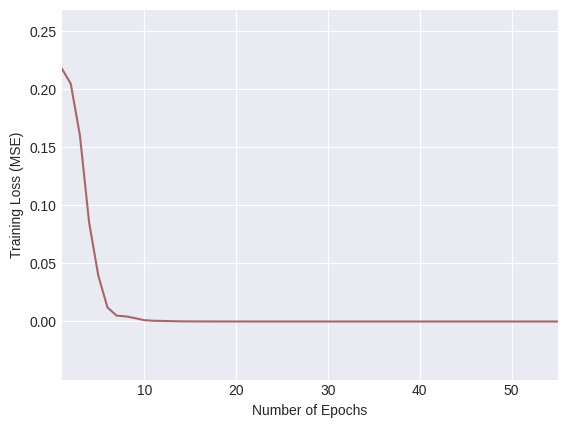

In [7]:
step =0
display(Image("catalyst_output/gt_output-00045.png"), display_id="my_image_stream")


losses_fake = np.array([15.0, 10.0, 5.0])
epochs_fake = list(range(1, len(losses_fake) + 1))
#plt.style.use('/home/local/KHQ/ayman.yousef/.config/matplotlib/stylelib/rose-pine-moon.mplstyle')
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-light.mplstyle')

fig, ax = plt.subplots()

line,  = ax.plot(epochs_fake,losses_fake, color='#A6666C')
display(fig, display_id='plots')

losses_to_plot = [] 

while step < 55:

    #print(" ====================== STEP {} ======================".format(step))

    omega, ux, uy, coords = read_from_fides()

    features = {
        'omega': omega,
        'ux': ux,
        'uy': uy
    }

    t0 = time.monotonic()
    vel_mag = np.sqrt(ux ** 2 + uy ** 2)

    omega = np.expand_dims(omega, axis=-1)
    vel_mag = np.expand_dims(vel_mag, axis =-1)

    features = np.concatenate((coords, omega , vel_mag), axis=-1)

    # * Run training

    x_tensor = torch.from_numpy(features).float()
    step_avg_loss  = train_loop(x_tensor, step)

    # ^ Prompt the user every 20 timesteps or so

    # ^ Plot the loss graph throughout, works alongside the visualization to help guide the user

    losses_to_plot.append(step_avg_loss)

    epochs = list(range(1, len(losses_to_plot) + 1))

    ax.set_xlim(epochs[0], epochs[-1])
    ax.set_ylim(min(losses_to_plot) - .05, max(losses_to_plot) + .05)
    ax.set_xlabel("Number of Epochs")
    ax.set_ylabel("Training Loss (MSE)")
    line.set_data(epochs,losses_to_plot)
    update_display(fig, display_id="plots")

    #plot_losses(np.array(losses_to_plot), line, fig)

    dt = (time.monotonic() - t0) * 1000

    step += 1

logger.info('Done.')